Назви ознак:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Форма X:
(442, 10)
Форма y:
(442,)
Форма X_train:
(353, 10)
Форма X_test:
(89, 10)
Форма y_train:
(353,)
Форма y_test:
(89,)
Навчання моделі без регуляризації
Епоха 1/50 | Loss: 29695.4512
Епоха 2/50 | Loss: 29691.0137
Епоха 3/50 | Loss: 29686.6465
Епоха 4/50 | Loss: 29682.3730
Епоха 5/50 | Loss: 29678.2559
Епоха 6/50 | Loss: 29674.2559
Епоха 7/50 | Loss: 29670.3164
Епоха 8/50 | Loss: 29666.4297
Епоха 9/50 | Loss: 29662.5391
Епоха 10/50 | Loss: 29658.5840
Епоха 11/50 | Loss: 29654.5215
Епоха 12/50 | Loss: 29650.3281
Епоха 13/50 | Loss: 29645.9434
Епоха 14/50 | Loss: 29641.3438
Епоха 15/50 | Loss: 29636.5039
Епоха 16/50 | Loss: 29631.3906
Епоха 17/50 | Loss: 29625.9746
Епоха 18/50 | Loss: 29620.2148
Епоха 19/50 | Loss: 29614.0898
Епоха 20/50 | Loss: 29607.5781
Епоха 21/50 | Loss: 29600.6523
Епоха 22/50 | Loss: 29593.2656
Епоха 23/50 | Loss: 29585.4004
Епоха 24/50 | Loss: 29577.0000
Епоха 25/50 | Loss: 29568.023

,Конфігурація,MAE,R²
0,Без регуляризації,143.607714,-3.873391
1,З регуляризацією (L2),142.335177,-3.805500


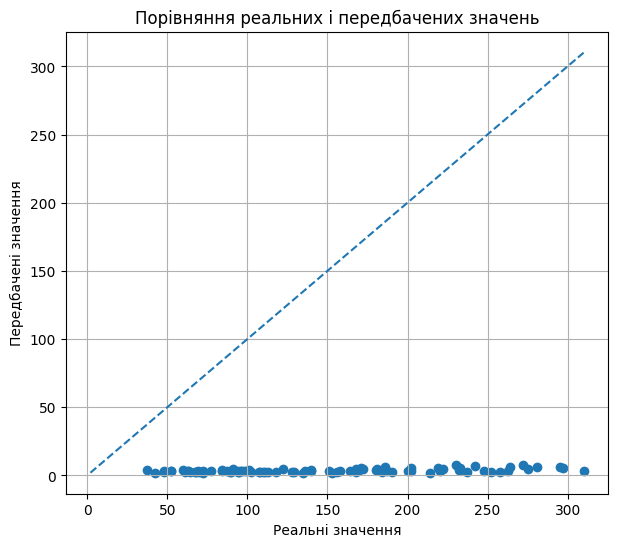

Висновок:
L2-регуляризація може зробити модель стабільнішою, оскільки вона зменшує занадто великі ваги нейромережі. Якщо R² з регуляризацією вищий або MAE нижчий, то регуляризація покращила якість моделі. Якщо результат трохи гірший, це означає, що регуляризація занадто сильно обмежила модель.

Найсильніше на результат можуть впливати ознаки, пов'язані з BMI, рівнем глюкози, віком та іншими медичними показниками, оскільки вони безпосередньо пов'язані зі станом здоров'я пацієнта.


In [4]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score


data = load_diabetes()

X = data.data
y = data.target

print("Назви ознак:")
print(data.feature_names)

print("Форма X:")
print(X.shape)

print("Форма y:")
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Форма X_train:")
print(X_train_scaled.shape)

print("Форма X_test:")
print(X_test_scaled.shape)

print("Форма y_train:")
print(y_train.shape)

print("Форма y_test:")
print(y_test.shape)





X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

input_size = X_train_scaled.shape[1]


def create_model():
    model = nn.Sequential(
        nn.Linear(input_size, 64),
        nn.ReLU(),

        nn.Linear(64, 32),
        nn.ReLU(),

        nn.Linear(32, 16),
        nn.ReLU(),

        nn.Linear(16, 1)
    )

    return model



def train_model(weight_decay_value):
    model = create_model()

    criterion = nn.MSELoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=weight_decay_value
    )

    epochs = 50

    for epoch in range(epochs):
        model.train()

        y_pred = model(X_train_tensor)

        loss = criterion(y_pred, y_train_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(
            f"Епоха {epoch + 1}/{epochs} | "
            f"Loss: {loss.item():.4f}"
        )

    return model



print("Навчання моделі без регуляризації")
model_without_reg = train_model(weight_decay_value=0)

print("\nНавчання моделі з L2-регуляризацією")
model_with_l2 = train_model(weight_decay_value=1e-4)


# Оцінка моделей

def evaluate_model(model):
    model.eval()

    with torch.no_grad():
        predictions = model(X_test_tensor).numpy().flatten()

    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    return mae, r2, predictions


mae_without, r2_without, pred_without = evaluate_model(model_without_reg)
mae_l2, r2_l2, pred_l2 = evaluate_model(model_with_l2)

results = pd.DataFrame({
    "Конфігурація": [
        "Без регуляризації",
        "З регуляризацією (L2)"
    ],
    "MAE": [
        mae_without,
        mae_l2
    ],
    "R²": [
        r2_without,
        r2_l2
    ]
})

display(results)


y_pred = pred_l2

plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Реальні значення")
plt.ylabel("Передбачені значення")
plt.title("Порівняння реальних і передбачених значень")

plt.grid(True)

plt.savefig(
    "diabetes_healthrisk_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Висновок:\n"
    "L2-регуляризація може зробити модель стабільнішою, "
    "оскільки вона зменшує занадто великі ваги нейромережі. "
    "Якщо R² з регуляризацією вищий або MAE нижчий, то регуляризація "
    "покращила якість моделі. Якщо результат трохи гірший, це означає, "
    "що регуляризація занадто сильно обмежила модель.\n\n"
    "Найсильніше на результат можуть впливати ознаки, пов'язані з BMI, "
    "рівнем глюкози, віком та іншими медичними показниками, оскільки вони "
    "безпосередньо пов'язані зі станом здоров'я пацієнта."
)